In [1]:
import torch
import torch.nn as nn
import torchvision
import numpy as np
from matplotlib import pyplot as plt

from model.classifier import Classifier, MyProgressBar
from model.spatial_transformer_classifier import SpatialTransformerClassifier  # Import spatial transformer classifier

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
torch.set_float32_matmul_precision('high')

In [3]:
from utils.transform_sequence import TransformSequence
from utils.transforms.apply import grid_resample
from utils.affine_transforms import AffineTransformation2D

transformations = [AffineTransformation2D.ROTATION.value,AffineTransformation2D.SHEARING_X.value,AffineTransformation2D.SHEARING_Y.value
                     ,AffineTransformation2D.SCALING_X.value,AffineTransformation2D.SCALING_Y.value]
domains = [(-torch.pi,torch.pi), ((-0.5, 0.5),), ((-0.5, 0.5),), ((1/1.3-1, 0.3),), ((1/1.3-1, 0.3),)]
n_samples = 17

transform_seq= TransformSequence(transformations, domains, neighbour_hood_size =0.25,application_method=grid_resample,device=device,reflect=True,use_individual_param_correction=False)

In [4]:
from its.transform import multi_transform
from dataset.mnist_no_pil import NoPILMNIST, NoPILFashionMNIST, AffineTransformDataset

dataset = 'mnist' # or 'fmnist'
batch_size = 128
#divide by 255 transform


if dataset == 'mnist':
    # essentially excluding either 6 or 9 as these would cause degenerations under 180 degree rotation
    dataset_train = NoPILMNIST("../experiment_files/data",train=True,download=True)
    n_classes = 10
    dataset_val_test = NoPILMNIST("../experiment_files/data",train=False,download=True)
    #split into validation and test set
    dataset_val, dataset_test_pre = #fix this, use val from train as this is what is usually expected.
elif dataset == 'fmnist':
    dataset_train = NoPILFashionMNIST("../experiment_files/data",train=True,download=True)
    n_classes = 10
    dataset_val_test = NoPILFashionMNIST("../experiment_files/data",train=False,download=True)
    #split into validation and test set
    dataset_val, dataset_test_pre = #fix this, use val from train as this is what is usually expected.




def transform(batch_size):
    n = torch.randint(0, n_samples, (batch_size, len(transformations)), device="cpu")
    x_test = torch.zeros(batch_size, 1, 28, 28, device="cpu")
    _, _, T = multi_transform(x_test, transformations, n, n_samples=n_samples, domain=domains)
    return T


dataset_test = AffineTransformDataset(dataset_test_pre,transform,return_transformation=False,batch_size=batch_size)


# Create transformed datasets for both training and testing
dataset_train_transformed = AffineTransformDataset(dataset_train, transform, return_transformation=False, batch_size=batch_size)


In [5]:
train_loader = torch.utils.data.DataLoader(dataset_train, batch_size=batch_size, shuffle=True, num_workers=4, persistent_workers=True)
val_loader = torch.utils.data.DataLoader(dataset_val, batch_size=batch_size, shuffle=False, num_workers=4, persistent_workers=True)
test_loader = torch.utils.data.DataLoader(dataset_test, batch_size=batch_size, shuffle=False, num_workers=4, persistent_workers=True)

# Create data loader for transformed training data
train_transformed_loader = torch.utils.data.DataLoader(dataset_train_transformed, batch_size=batch_size, shuffle=True, num_workers=4, persistent_workers=True)


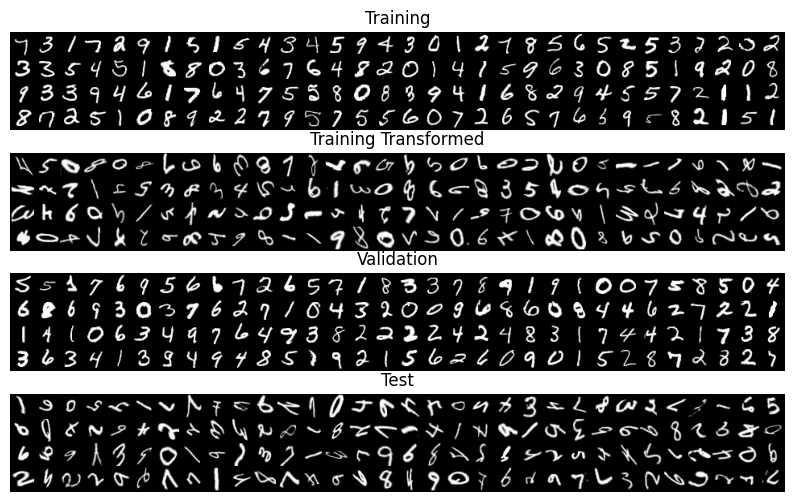

In [6]:
#test images
fig, axs = plt.subplots(nrows=4, ncols=1, figsize=(10, 6))

axs[0].imshow(torchvision.utils.make_grid(next(iter(train_loader))[0], nrow=batch_size//4).permute(1, 2, 0).cpu())
axs[1].imshow(torchvision.utils.make_grid(next(iter(train_transformed_loader))[0], nrow=batch_size//4).permute(1, 2, 0).cpu())
axs[2].imshow(torchvision.utils.make_grid(next(iter(val_loader))[0], nrow=batch_size//4).permute(1, 2, 0).cpu())
axs[3].imshow(torchvision.utils.make_grid(next(iter(test_loader))[0], nrow=batch_size//4).permute(1, 2, 0).cpu())
axs[0].set_title('Training')
axs[1].set_title('Training Transformed')
axs[2].set_title('Validation')
axs[3].set_title('Test')

for ax in axs.flat:
    ax.axis('off')

In [7]:
import pytorch_lightning as pl
import os

model_path = f'../model/{dataset}.pth'

model = nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),  # Output: 32x28x28
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),                  # Output: 32x14x14
    nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),  # Output: 64x14x14
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),                  # Output: 64x7x7
    nn.Flatten(),
    nn.Linear(64 * 7 * 7, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
)


# Check if model is already trained
if os.path.exists(model_path):
    print(f"Loading model from {model_path}")
    model.load_state_dict(torch.load(model_path))
else:
    print(f"Training model and will save to {model_path}")
    lightning_model = Classifier(model, optimizer_class =  torch.optim.AdamW, optimizer_params = {"lr": 1e-3})
    progress_bar = MyProgressBar()
    trainer = pl.Trainer(
        accelerator="cuda",
        max_epochs=10,
        precision="16-mixed",
        callbacks=[progress_bar],
    )
    # Train the model
    trainer.fit(lightning_model, train_loader,val_loader)
    # Test the model
    #trainer.test(lightning_model, test_loader)
    # Save model
    torch.save(model.state_dict(), model_path)
    print(f"Model saved to {model_path}")


Loading model from ../model/mnist.pth


In [8]:
# Define localization network for spatial transformer
localization_net = nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),  # Output: 32x28x28
    nn.GELU(),
    nn.MaxPool2d(kernel_size=2, stride=2),                  # Output: 32x14x14
    nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),  # Output: 64x14x14
    nn.GELU(),
    nn.MaxPool2d(kernel_size=2, stride=2),                  # Output: 64x7x7
    nn.Flatten(),
    nn.Linear(64 * 7 * 7, 128),
    nn.GELU(),

)

# Calculate the output dimension of the localization network
with torch.no_grad():
    dummy_input = torch.zeros(1, 1, 28, 28)
    loc_output = localization_net(dummy_input)
    localization_dim = loc_output.numel()  # Get the flattened size
    print(f"Localization network output dimension: {localization_dim}")

# Create spatial transformer model (6 parameters for 2D affine transformation)
spatial_model_path = f'../model/{dataset}_spatial_transformer.pth'

Localization network output dimension: 128


In [9]:
from utils.transformation_problem import TransformationProblem



# Check if spatial transformer model exists
if os.path.exists(spatial_model_path) and True:
    print(f"Loading spatial transformer model from {spatial_model_path}")
    spatial_transformer = SpatialTransformerClassifier(
        main_model=model,
        transformation_problem=TransformationProblem(None,transform_seq),
        localization_net=localization_net,
        localization_dim=localization_dim,
        freeze_main=True  # Freeze the base model
    )
    spatial_transformer.load_state_dict(torch.load(spatial_model_path))
else:
    print(f"Training spatial transformer model and will save to {spatial_model_path}")
    spatial_transformer = SpatialTransformerClassifier(
        main_model=model,
        localization_net=localization_net,
        localization_dim=localization_dim,
        transformation_problem=TransformationProblem(None,transform_seq),
        freeze_main=True,  # Freeze the base model
        optimizer_params={"lr": 1e-3},
        optimizer_class = torch.optim.Adam,
        train_noise_scale = 0.01
    )

    # Train the spatial transformer model on transformed data
    trainer = pl.Trainer(
        accelerator="cuda",
        max_epochs=30,
        precision="16-mixed",
        callbacks=[MyProgressBar()]
    )
    trainer.fit(spatial_transformer, train_transformed_loader, test_loader)

    # Save the spatial transformer model
    torch.save(spatial_transformer.state_dict(), spatial_model_path)
    print(f"Spatial transformer model saved to {spatial_model_path}")


Loading spatial transformer model from ../model/mnist_spatial_transformer.pth


In [10]:
#calibrate the model
#from confidence.calibration import TemperatureCalibrationModule
#if model is not temperature calibrated
#if isinstance(model, TemperatureCalibrationModule):
    #model = model.model
#model = TemperatureCalibrationModule(model,per_logit=True).cuda()
#model.fit(test_loader)


In [11]:
model.cuda()
spatial_transformer.cuda()

SpatialTransformerClassifier(
  (main_model): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=3136, out_features=128, bias=True)
    (8): ReLU()
    (9): Linear(in_features=128, out_features=10, bias=True)
  )
  (localization_net): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): GELU(approximate='none')
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): GELU(approximate='none')
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_

In [12]:
with torch.no_grad():
    model.eval()
    test_acc = 0
    for data, target in val_loader:
        data, target = data.cuda(), target.cuda()
        output = model(data)
        test_acc += output.argmax(dim=-1).eq(target).sum().item()
    test_acc /= len(dataset_val)
    print(f'Mean accuracy on the val set: {test_acc}.')

Mean accuracy on the val set: 0.9896.


In [13]:
# Evaluate both models on the transformed test set
with torch.no_grad():
    model.eval()
    base_acc = 0
    for data, target in test_loader:
        data, target = data.cuda(), target.cuda()
        output = model(data)
        base_acc += output.argmax(dim=-1).eq(target).sum().item()
    base_acc /= len(dataset_test)
    print(f'Base model accuracy on the transformed test set: {base_acc}.')

    spatial_transformer.eval()
    st_acc = 0
    for data, target in test_loader:
        data, target = data.cuda(), target.cuda()
        output = spatial_transformer(data)
        st_acc += output.argmax(dim=-1).eq(target).sum().item()
    st_acc /= len(dataset_test)
    print(f'Spatial transformer accuracy on the transformed test set: {st_acc}.')

Base model accuracy on the transformed test set: 0.3796.
Spatial transformer accuracy on the transformed test set: 0.8034.


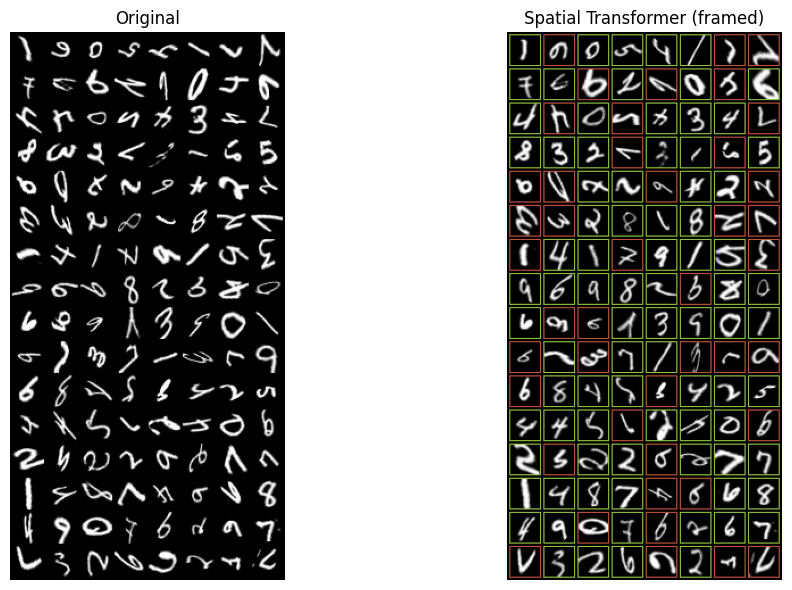

In [14]:
with torch.no_grad():
    # 1. Load a batch
    data, target = next(iter(test_loader))
    data, target = data.cuda(), target.cuda()

    # 2. Apply spatial transformer
    transformed = spatial_transformer.transform_input(data)

    # 3. Get predictions and correctness mask
    preds = model(transformed).argmax(dim=1)
    correct = preds.eq(target)

    # 4. Define frame colors
    green = torch.tensor((143, 194, 62))[:, None] / 255.
    red   = torch.tensor((194,  80, 62))[:, None] / 255.

    # 5. Draw colored frames on transformed images
    imgs = transformed.repeat(1, 3, 1, 1)  # ensure 3 channels
    for img, is_correct in zip(imgs, correct):
        color = green if is_correct else red
        img[:,   0, :] = color
        img[:,  -1, :] = color
        img[:, :,   0] = color
        img[:, :,  -1] = color

    # 6. Plot original vs. framed outputs
    fig, axs = plt.subplots(1, 2, figsize=(12, 6))
    axs[0].imshow(torchvision.utils.make_grid(data.cpu(), nrow=8).permute(1, 2, 0), cmap='gray')
    axs[0].set_title('Original')
    axs[0].axis('off')

    axs[1].imshow(torchvision.utils.make_grid(imgs.cpu(), nrow=8).permute(1, 2, 0))
    axs[1].set_title('Spatial Transformer (framed)')
    axs[1].axis('off')

    plt.tight_layout()
    plt.show()

In [15]:
from confidence.base_confidence import EnergyConfidence, SinglePassConfidence
from its.search import InverseTransformationSearch
confidence_module = SinglePassConfidence(model, EnergyConfidence())
its = InverseTransformationSearch(model, transformation=transformations, domain=domains,
                                  n_samples=17, n_hypotheses=1, mc_steps=1,
                                  change_of_mind='score', en_unique_class_condition=True,gaussian_filter_channel_wise=False,confidence_module=confidence_module)



with torch.no_grad():
    model.eval()
    test_acc = 0
    for d, (data, target) in enumerate(test_loader):
        data, target = data.cuda(), target.cuda()
        data_canonic, embedding = its.infer(data, plot_idx=None)
        # pick the class of the leading hypothesis
        output = embedding.argmax(dim=-1)[:, 0]
        test_acc += output.eq(target).sum().item()
    test_acc /= len(dataset_test)
    print(f'Mean accuracy on the transformed test set [but with ITS]: {test_acc}.')

Mean accuracy on the transformed test set [but with ITS]: 0.7174.


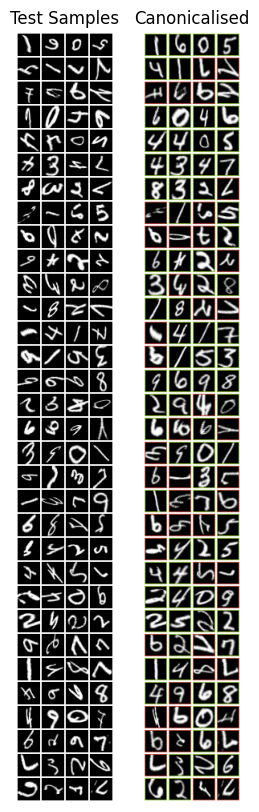

In [16]:
data, target = next(iter(test_loader))
data_canonic, embedding = its.infer(data.cuda())
output = embedding.argmax(dim=-1)[:, 0]
correct_label = output.eq(target.cuda())

# highlight correct predictions with green frame
green = torch.tensor((143, 194, 62))[:, None] / 255.
red = torch.tensor((194, 80, 62))[:, None] / 255.
data_canonic = data_canonic[:, 0].repeat(1, 3, 1, 1)
for image, correct in zip(data_canonic, correct_label):
    color = green if correct else red
    image[:, :, 0] = color
    image[:, :, 27] = color
    image[:, 0, :] = color
    image[:, 27, :] = color

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(3, 10))

axs[0].imshow(torchvision.utils.make_grid(data.cpu(), nrow=4, pad_value=1).permute(1, 2, 0), cmap='gray')
axs[1].imshow(torchvision.utils.make_grid(data_canonic.cpu(), nrow=4, pad_value=1).permute(1, 2, 0))

axs[0].set_title('Test Samples')
axs[1].set_title('Canonicalised')

for ax in axs.flat:
    ax.axis('off')

In [17]:
from confidence.utils import ModelInputWrapper

#use model wrapper to extract the embeddings
dual_ouput_model = ModelInputWrapper(model,'9',flatten=True)

In [18]:
#extract embeddings and fit NNDistanceConfidence()
embeddings = []
classes = []
for batch in train_loader:
    emb, _ = dual_ouput_model(batch[0].cuda())
    embeddings.append(emb.detach().cpu().numpy())
    classes.append(batch[1].detach().cpu().numpy())

embeddings = np.vstack(embeddings)
classes = np.hstack(classes)

#randomly sample 5000 ones
if embeddings.shape[0] > 5000:
    indices = np.random.choice(embeddings.shape[0], 5000, replace=False)
    embeddings = embeddings[indices]



In [19]:
from confidence.nn import NNDistanceConfidence

#test nearrest neigbhoor confidence
nearest_neighbor_confidence = NNDistanceConfidence(index_type="ivfpq", number_of_neighbors=3)
nearest_neighbor_confidence.fit(embeddings)
nearest_neighbor_confidence.cuda()
from confidence.base_confidence import SplitConfidence, SinglePassConfidence

conf_split = SplitConfidence(nearest_neighbor_confidence, EnergyConfidence(), mult=True, b=1.0)
conf_2 = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem = TransformationProblem(conf_2, transform_seq, consolidate_method="consolidate_simple")

In [20]:
import search.shgo
import importlib

importlib.reload(search.shgo)
di = search.shgo.SHGO(selection_method="topk")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem, data.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

Mean accuracy on the transformed test set with GD: 0.8388.


In [21]:
from confidence.base_confidence import CrossEntropyConfidence,EnergyConfidence


In [22]:
nearest_neighbor_confidence = NNDistanceConfidence(index_type="ivfpq", number_of_neighbors=3)
nearest_neighbor_confidence.fit(embeddings)
nearest_neighbor_confidence.cuda()
from confidence.base_confidence import SplitConfidence, SinglePassConfidence

conf_split_guided = SplitConfidence(nearest_neighbor_confidence, CrossEntropyConfidence(), mult=True)
conf_split_unguided = SplitConfidence(nearest_neighbor_confidence, EnergyConfidence(), mult=True)

In [23]:


conf_guided = SinglePassConfidence(dual_ouput_model, conf_split_guided,index=1)
conf_unguided = SinglePassConfidence(dual_ouput_model, conf_split_unguided,index=1)
problem_guided = TransformationProblem(conf_guided, transform_seq, consolidate_method="consolidate_simple")

problem_unguided = TransformationProblem(conf_unguided, transform_seq, consolidate_method="consolidate_simple")


In [24]:
import search.shgo
import importlib

importlib.reload(search.shgo)
di = search.shgo.SHGO(selection_method="topk")
test_acc_sim = 0
stop_at = 1
counter = 0
regression_data = []
regression_target =[]

for d, (data, target) in enumerate(train_transformed_loader):
    data, target = data.cuda(), target.cuda()
    regression_data.append(data.detach().cpu().numpy())
    res = di.optimize(problem_guided, data.cuda(),y=target.cuda())
    regression_target.append(res[0].detach().cpu().numpy())

    # Apply the transformation and get predictions
    x_transformed2 = problem.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'With class knowledge we can define a canonical represenation of the data: {test_acc_sim}.')

With class knowledge we can define a canonical represenation of the data: 0.9997166666666667.


In [ ]:
#this is very unlikely to work due to noise and symetires.

In [25]:

class RegressionDataset(torch.utils.data.Dataset):

    def __init__(self, data, target_params):
        self.data = data
        self.target_params = target_params

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        x = self.data[idx]
        target_params = self.target_params[idx]
        return x, target_params


In [26]:
regression_target = np.vstack(regression_target)
regression_target = torch.tensor(regression_target, dtype=torch.float32).cpu()
regression_data = np.vstack(regression_data)
regression_data = torch.tensor(regression_data, dtype=torch.float32).cpu()
regression_dataset = RegressionDataset(regression_data, regression_target)
regression_dataloader = torch.utils.data.DataLoader(regression_dataset, batch_size=batch_size, shuffle=True, num_workers=0)


(-0.5, 301.5, 301.5, -0.5)

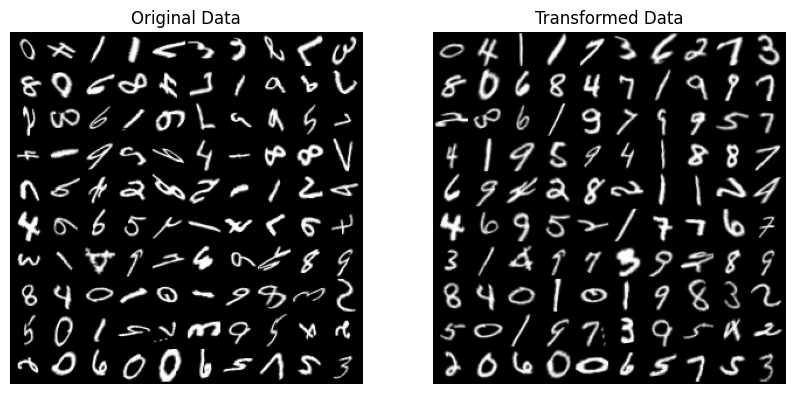

In [27]:
#plot dataset and transformed dataset sample

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
x,p = regression_dataset[:100]

plt.imshow(torchvision.utils.make_grid(x, nrow=10).permute(1, 2, 0).cpu())
plt.title('Original Data')
plt.axis('off')

plt.subplot(1, 2, 2)

x_transformed = transform_seq.transform(x, p)
plt.imshow(torchvision.utils.make_grid(x_transformed, nrow=10).permute(1, 2, 0).cpu())
plt.title('Transformed Data')
plt.axis('off')





In [28]:
def train_regression(model, dataloader, optimizer, device,epochs=10):
    model.train()
    for i in range(epochs):
        total = 0
        for x, target_params in dataloader:
            x = x.to(device)
            target_params = target_params.to(device)

            optimizer.zero_grad()
            preds, loss = model.regress_target(x, target_params,use_mse=True)
            loss.backward()
            optimizer.step()

            total += loss.item()

        print(f"Epoch {i+1}/{epochs}, Loss: {total/len(dataloader)}")



In [29]:
opt = spatial_transformer.configure_optimizers()

In [47]:
train_regression(spatial_transformer.cuda(), regression_dataloader, opt, device,epochs=25)


Epoch 1/25, Loss: 0.14458132903776696
Epoch 2/25, Loss: 0.13356169464110312
Epoch 3/25, Loss: 0.12925946210493158
Epoch 4/25, Loss: 0.12506859031503897
Epoch 5/25, Loss: 0.12135771307736826
Epoch 6/25, Loss: 0.11851074713379589
Epoch 7/25, Loss: 0.11476042458434095
Epoch 8/25, Loss: 0.1116518338383642
Epoch 9/25, Loss: 0.10805858525513078
Epoch 10/25, Loss: 0.10449436631029857
Epoch 11/25, Loss: 0.10211023863857743
Epoch 12/25, Loss: 0.09870286829181826
Epoch 13/25, Loss: 0.0966456828674655
Epoch 14/25, Loss: 0.09338334386250866
Epoch 15/25, Loss: 0.09043074088659622
Epoch 16/25, Loss: 0.08772746344079087
Epoch 17/25, Loss: 0.0851331968138467
Epoch 18/25, Loss: 0.08256491559591375
Epoch 19/25, Loss: 0.08023083747735918
Epoch 20/25, Loss: 0.07731496450552808
Epoch 21/25, Loss: 0.0758445645128486
Epoch 22/25, Loss: 0.07317940144936667
Epoch 23/25, Loss: 0.07099370378802326
Epoch 24/25, Loss: 0.06926304008215983
Epoch 25/25, Loss: 0.06716819110709721


In [51]:
spatial_transformer.conf_module = None

In [52]:
#trainer = pl.Trainer(
#        accelerator="cuda",
#        max_epochs=5,
#        precision="16-mixed",
#        callbacks=[MyProgressBar()]
#)
#trainer.fit(spatial_transformer, train_transformed_loader, test_loader)

Using 16bit Automatic Mixed Precision (AMP)
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name             | Type       | Params | Mode
-------------------------------------------------------
0 | main_model       | Sequential | 421 K  | eval
1 | localization_net | Sequential | 420 K  | eval
2 | regression_net   | Linear     | 645    | eval
-------------------------------------------------------
420 K     Trainable params
421 K     Non-trainable params
842 K     Total params
3.371     Total estimated model params size (MB)
0         Modules in train mode
22        Modules in eval mode


Epoch 4: 100%|██████████| 469/469 [00:07<00:00, 62.27it/s, v_num=122, train_loss=0.843, train_reg=0.0166, val_loss=1.000, val_reg=0.0146, val_acc=0.817]

`Trainer.fit` stopped: `max_epochs=5` reached.


Epoch 4: 100%|██████████| 469/469 [00:07<00:00, 62.13it/s, v_num=122, train_loss=0.843, train_reg=0.0166, val_loss=1.000, val_reg=0.0146, val_acc=0.817]


In [33]:
spatial_transformer.cuda()

SpatialTransformerClassifier(
  (main_model): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=3136, out_features=128, bias=True)
    (8): ReLU()
    (9): Linear(in_features=128, out_features=10, bias=True)
  )
  (localization_net): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): GELU(approximate='none')
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): GELU(approximate='none')
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_

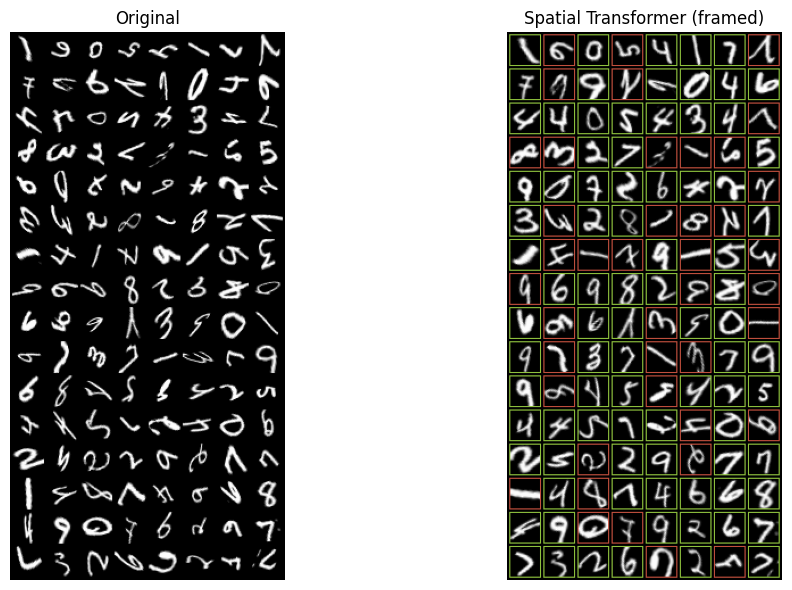

In [48]:
with torch.no_grad():
    # 1. Load a batch
    data, target = next(iter(test_loader))
    data, target = data.cuda(), target.cuda()

    # 2. Apply spatial transformer
    transformed = spatial_transformer.transform_input(data)

    # 3. Get predictions and correctness mask
    preds = model(transformed).argmax(dim=1)
    correct = preds.eq(target)

    # 4. Define frame colors
    green = torch.tensor((143, 194, 62))[:, None] / 255.
    red = torch.tensor((194, 80, 62))[:, None] / 255.

    # 5. Draw colored frames on transformed images
    imgs = transformed.repeat(1, 3, 1, 1)  # ensure 3 channels
    for img, is_correct in zip(imgs, correct):
        color = green if is_correct else red
        img[:, 0, :] = color
        img[:, -1, :] = color
        img[:, :, 0] = color
        img[:, :, -1] = color

    # 6. Plot original vs. framed outputs
    fig, axs = plt.subplots(1, 2, figsize=(12, 6))
    axs[0].imshow(torchvision.utils.make_grid(data.cpu(), nrow=8).permute(1, 2, 0), cmap='gray')
    axs[0].set_title('Original')
    axs[0].axis('off')

    axs[1].imshow(torchvision.utils.make_grid(imgs.cpu(), nrow=8).permute(1, 2, 0))
    axs[1].set_title('Spatial Transformer (framed)')
    axs[1].axis('off')

    plt.tight_layout()
    plt.show()

In [49]:
# Evaluate both models on the transformed test set
with torch.no_grad():
    spatial_transformer.eval()
    st_acc = 0
    for data, target in test_loader:
        data, target = data.cuda(), target.cuda()
        output = spatial_transformer(data)
        st_acc += output.argmax(dim=-1).eq(target).sum().item()
    st_acc /= len(dataset_test)
    print(f'Spatial transformer accuracy on the transformed test set: {st_acc}.')


Spatial transformer accuracy on the transformed test set: 0.7074.


In [50]:
# Evaluate both models on the transformed test set
with torch.no_grad():
    spatial_transformer.eval()
    confs =[]
    correct =[]
    st_acc = 0
    for data, target in test_loader:
        data, target = data.cuda(), target.cuda()
        data_transformed = spatial_transformer.transform_input(data)
        conf,output = conf_unguided(data_transformed)
        confs.append(conf.cpu().numpy())
        same =output.argmax(dim=-1).eq(target)
        correct.append(same.cpu().numpy())
        st_acc += same.sum().item()
    st_acc /= len(dataset_test)
    print(f'Spatial transformer accuracy on the transformed test set: {st_acc}.')

Spatial transformer accuracy on the transformed test set: 0.7074.


In [37]:
correct = np.hstack(correct)
confs = np.hstack(confs)

confs_correct = confs[correct]
confs_incorrect = confs[~correct]

(array([ 5., 31., 50., 74., 69., 92., 80., 71., 78., 66., 53., 34., 47.,
        32., 29., 22., 31., 16., 19., 14., 14.,  9.,  7.,  9.,  1., 10.,
         2.,  3.,  2.,  0.,  3.,  1.,  1.,  4.,  4.,  0.,  1.,  1.,  1.,
         0.,  1.,  1.,  1.,  1.,  0.,  0.,  0.,  0.,  1.,  1.]),
 array([0.00044715, 0.00147139, 0.00249563, 0.00351987, 0.00454411,
        0.00556835, 0.0065926 , 0.00761684, 0.00864108, 0.00966532,
        0.01068956, 0.0117138 , 0.01273804, 0.01376228, 0.01478652,
        0.01581076, 0.016835  , 0.01785924, 0.01888348, 0.01990772,
        0.02093196, 0.0219562 , 0.02298044, 0.02400468, 0.02502892,
        0.02605316, 0.0270774 , 0.02810165, 0.02912589, 0.03015013,
        0.03117437, 0.03219861, 0.03322285, 0.03424709, 0.03527133,
        0.03629557, 0.03731981, 0.03834405, 0.03936829, 0.04039253,
        0.04141677, 0.04244101, 0.04346525, 0.0444895 , 0.04551373,
        0.04653798, 0.04756222, 0.04858646, 0.0496107 , 0.05063494,
        0.05165918]),
 <BarContainer

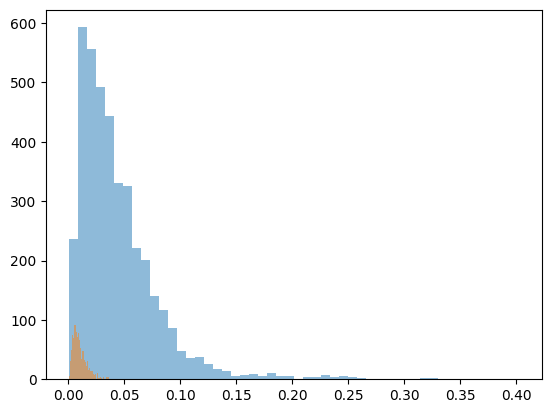

In [38]:
plt.hist(confs_correct, bins=50, alpha=0.5, label='Correct')
plt.hist(confs_incorrect, bins=50, alpha=0.5, label='Incorrect')

In [39]:
conf_search = []
correct_search = []

In [40]:
# Evaluate both models on the transformed test set
with torch.no_grad():
    spatial_transformer.eval()
    st_acc = 0
    for data, target in test_loader:
        data, target = data.cuda(), target.cuda()
        best_param,best_error,best_class = di.optimize(problem_unguided, data.cuda())
        conf_search.append(-best_error.cpu().numpy())
        same =best_class.squeeze(-1).eq(target)
        correct_search.append(same.cpu().numpy())
        st_acc += same.sum().item()
    st_acc /= len(dataset_test)
    print(f'Spatial transformer accuracy on the transformed test set: {st_acc}.')

Spatial transformer accuracy on the transformed test set: 0.841.


In [41]:
conf_search = np.hstack(conf_search)
correct_search = np.hstack(correct_search)
conf_search_correct = conf_search[correct_search]
conf_search_incorrect = conf_search[~correct_search]

(array([ 5., 31., 50., 74., 69., 92., 80., 71., 78., 66., 53., 34., 47.,
        32., 29., 22., 31., 16., 19., 14., 14.,  9.,  7.,  9.,  1., 10.,
         2.,  3.,  2.,  0.,  3.,  1.,  1.,  4.,  4.,  0.,  1.,  1.,  1.,
         0.,  1.,  1.,  1.,  1.,  0.,  0.,  0.,  0.,  1.,  1.]),
 array([0.00044715, 0.00147139, 0.00249563, 0.00351987, 0.00454411,
        0.00556835, 0.0065926 , 0.00761684, 0.00864108, 0.00966532,
        0.01068956, 0.0117138 , 0.01273804, 0.01376228, 0.01478652,
        0.01581076, 0.016835  , 0.01785924, 0.01888348, 0.01990772,
        0.02093196, 0.0219562 , 0.02298044, 0.02400468, 0.02502892,
        0.02605316, 0.0270774 , 0.02810165, 0.02912589, 0.03015013,
        0.03117437, 0.03219861, 0.03322285, 0.03424709, 0.03527133,
        0.03629557, 0.03731981, 0.03834405, 0.03936829, 0.04039253,
        0.04141677, 0.04244101, 0.04346525, 0.0444895 , 0.04551373,
        0.04653798, 0.04756222, 0.04858646, 0.0496107 , 0.05063494,
        0.05165918]),
 <BarContainer

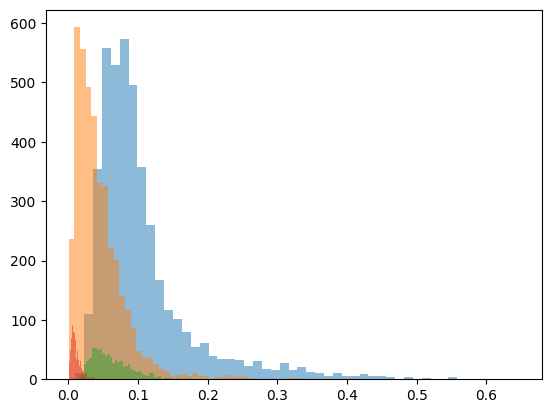

In [42]:
plt.hist(conf_search_correct, bins=50, alpha=0.5, label='Correct')
plt.hist(confs_correct, bins=50, alpha=0.5, label='Correct Non Search')
plt.hist(conf_search_incorrect, bins=50, alpha=0.5, label='Incorrect')
plt.hist(confs_incorrect, bins=50, alpha=0.5, label='Incorrect Non Search')

In [43]:
def find_optimal_threshold(correct1, correct2, confidence1, cost_classifier2=0.0):
    thresholds = np.linspace(0, 1, 1000)
    best_acc = 0
    best_thresh = 0
    best_usage = 0

    for t in thresholds:
        use_classifier1 = confidence1 >= t
        use_classifier2 = ~use_classifier1

        correct = (use_classifier1 & correct1) | (use_classifier2 & correct2)
        accuracy = np.mean(correct) - cost_classifier2 * np.mean(use_classifier2)
        usage_rate = np.mean(use_classifier2)  # or use np.sum(use_classifier2) for count

        if accuracy > best_acc:
            best_acc = accuracy
            best_thresh = t
            best_usage = usage_rate

    return best_thresh, best_acc, best_usage

In [46]:
find_optimal_threshold(correct, correct_search, confs, cost_classifier2=0.00)

(0.014014014014014014, 0.8802, 0.276)

In [45]:
(confs >= 0.02).mean()

0.6094